# Task2 (Google Colab)
### Whisper + LoRA · Content Head · Re-encoder · Evaluation

Runs on **real L2-ARCTIC audio** from Google Drive.

**Before running:** Set `Runtime → Change runtime type → GPU (T4)`

---

## Cell 0 — Install + Detect GPU

In [ ]:
!pip install -q transformers peft torchaudio jiwer accelerate soundfile

import torch
import torch.nn as nn
import torch.nn.functional as F
import json, os, zipfile

if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'\u2705 GPU detected: {torch.cuda.get_device_name(0)}')
else:
    device = torch.device('cpu')
    print('\u26a0\ufe0f  No GPU — using CPU')

print(f'PyTorch : {torch.__version__}')
print(f'Device  : {device}')

✅ GPU detected: NVIDIA RTX PRO 6000 Blackwell Server Edition
PyTorch : 2.10.0+cu128
Device  : cuda


---
## Cell 1 — Mount Google Drive + Extract Audio

Uses the same paths as Task 1 notebook:
- Zips: `MirrorSpeech/l2arctic_zips/`
- Splits: `MirrorSpeech/splits/`
- Extracted L2 audio: `/content/data/l2arctic/`
- **LibriSpeech (optional on Drive):** `MirrorSpeech/librispeech/LibriSpeech/...` — same folder layout as your local `april_17/MirrorSpeech/librispeech`. Cell 2 resolves native rows to this path.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ZIP_DIR = '/content/drive/MyDrive/MirrorSpeech/l2arctic_zips'
EXTRACT_PATH  = '/content/data/l2arctic'
SPLITS_DIR    = '/content/drive/MyDrive/MirrorSpeech/splits'
L2ARCTIC_PATH = '/content/data/l2arctic'

SPEAKERS = ['RRBI','SVBI','TNI','NJS',
            'HQTV','MBMPS','NCC','TXHC',
            'HJK','HKK','YDCK','YKWK',
            'ABA','YBAA','SKA','ZHAA']

os.makedirs(EXTRACT_PATH, exist_ok=True)

for spk in SPEAKERS:
    zip_path = f'{DRIVE_ZIP_DIR}/{spk}.zip'
    out_path = f'{EXTRACT_PATH}/{spk}'
    if os.path.exists(out_path):
        print(f'  \u23ed\ufe0f  {spk} already extracted')
        continue
    if not os.path.exists(zip_path):
        print(f'  \u274c  {spk}.zip not found in Drive')
        continue
    print(f'  Extracting {spk}...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(EXTRACT_PATH)

print(f'\n\u2705 All speakers extracted to {EXTRACT_PATH}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  ⏭️  RRBI already extracted
  ⏭️  SVBI already extracted
  ⏭️  TNI already extracted
  ⏭️  NJS already extracted
  ⏭️  HQTV already extracted
  ⏭️  MBMPS already extracted
  ⏭️  NCC already extracted
  ⏭️  TXHC already extracted
  ⏭️  HJK already extracted
  ⏭️  HKK already extracted
  ⏭️  YDCK already extracted
  ⏭️  YKWK already extracted
  ⏭️  ABA already extracted
  ⏭️  YBAA already extracted
  ⏭️  SKA already extracted
  ⏭️  ZHAA already extracted

✅ All speakers extracted to /content/data/l2arctic


In [ ]:
import torchaudio

# Optional: only if Libri is NOT already on Drive under MirrorSpeech/librispeech/
# (Same tree as local: librispeech/LibriSpeech/dev-clean/...)
LIBRISPEECH_PATH = '/content/data/librispeech'
LIBRISPEECH_SPLIT = 'dev-clean'
os.makedirs(LIBRISPEECH_PATH, exist_ok=True)
print(f"Downloading LibriSpeech '{LIBRISPEECH_SPLIT}' → {LIBRISPEECH_PATH} (~344 MB, one-time per fresh runtime)...")
_libri = torchaudio.datasets.LIBRISPEECH(root=LIBRISPEECH_PATH, url=LIBRISPEECH_SPLIT, download=True)
_root = os.path.join(LIBRISPEECH_PATH, 'LibriSpeech', LIBRISPEECH_SPLIT)
print(f"✅ LibriSpeech ready: {len(_libri):,} utterances | on disk: {os.path.isdir(_root)}")

✅ LibriSpeech ready: 2,703 utterances | on disk: True


---
## Cell 2 — Load Splits + Fix Paths

Load the splits saved by Task 1 and fix `wav_path`:
- **L2-ARCTIC** → `/content/data/l2arctic/{speaker}/wav/...`
- **LibriSpeech** → `/content/drive/MyDrive/MirrorSpeech/librispeech/...` when that folder exists (matches repo layout); else `/content/data/librispeech/...` if you ran the download cell.

In [ ]:
from collections import Counter

SPLITS_DIR    = '/content/drive/MyDrive/MirrorSpeech/splits'
L2ARCTIC_PATH = '/content/data/l2arctic'
DATA_ROOT     = os.path.dirname(L2ARCTIC_PATH)  # e.g. /content/data

def load_and_fix_paths(split_name):
    """L2: .../l2arctic/{speaker}/wav/{file}. Libri: same repo layout on Drive as local —
    MirrorSpeech/librispeech/LibriSpeech/... (splits store data/librispeech/...)."""
    path    = f'{SPLITS_DIR}/{split_name}.json'
    records = json.load(open(path))
    mirror_root = os.path.dirname(SPLITS_DIR)  # e.g. .../MirrorSpeech (parent of splits/)
    for r in records:
        orig = r['wav_path']
        norm = orig.replace('\\', '/')
        if 'librispeech' in norm.lower():
            tail = norm.split('librispeech/', 1)[-1]  # LibriSpeech/dev-clean/...
            drive_libri = os.path.join(mirror_root, 'librispeech', tail)
            if norm.startswith('data/'):
                content_libri = os.path.join('/content', norm)
            else:
                content_libri = os.path.join(DATA_ROOT, norm.split('data/', 1)[-1]) if 'data/' in norm else drive_libri
            if os.path.isfile(drive_libri):
                r['wav_path'] = drive_libri
            elif os.path.isfile(content_libri):
                r['wav_path'] = content_libri
            else:
                r['wav_path'] = drive_libri  # expect Drive: .../MirrorSpeech/librispeech/...
        else:
            r['wav_path'] = os.path.join(
                L2ARCTIC_PATH,
                r['speaker'],
                'wav',
                os.path.basename(orig),
            )
    return records

config        = json.load(open(f'{SPLITS_DIR}/config.json'))
train_records = load_and_fix_paths('train')
val_records   = load_and_fix_paths('val')
test_records  = load_and_fix_paths('test')

ACCENT_MAP = {int(k): v for k, v in config['id_to_accent'].items()}

print('=== PROJECT DATASET ===')
print(f'Train : {len(train_records):,} samples')
print(f'Val   : {len(val_records):,} samples')
print(f'Test  : {len(test_records):,} samples')
print(f'\nAccent classes:')
for aid, cnt in sorted(Counter(r['accent_id'] for r in train_records).items()):
    print(f'  {ACCENT_MAP[aid]:10s} (id={aid}): {cnt:,}')
print(f'\nSample path  : {train_records[0]["wav_path"]}')
print(f'File exists  : {os.path.exists(train_records[0]["wav_path"])}')
_ex = next((r for r in train_records if r.get('accent_id') == 4), None)
if _ex:
    print(f"\nNative / Libri (first train row): {_ex['wav_path']}")
    print(f"  File exists : {os.path.isfile(_ex['wav_path'])}")
    if not os.path.isfile(_ex['wav_path']):
        print('  → Put Libri under Drive: MyDrive/MirrorSpeech/librispeech/ (same as local repo), or run Cell 1b.')

=== PROJECT DATASET ===
Train : 14,829 samples
Val   : 1,853 samples
Test  : 1,855 samples

Accent classes:
  indian     (id=0): 3,599
  mandarin   (id=1): 3,649
  korean     (id=2): 2,728
  arabic     (id=3): 2,686
  native     (id=4): 2,167

Sample path  : /content/data/l2arctic/NJS/wav/arctic_b0385.wav
File exists  : True

Native / Libri (first train row): /content/drive/MyDrive/MirrorSpeech/librispeech/LibriSpeech/dev-clean/2803/161169/2803-161169-0006.flac
  File exists : True


---
## Cell 3 — Load Real Audio (L2-ARCTIC + LibriSpeech native)

One clip per **accent_id** in your splits (up to 5: Indian, Mandarin, Korean, Arabic, Native). Native uses LibriSpeech `.flac` when Task 1 merged it.

In [ ]:
import torchaudio

num_accent_classes = int(config.get('num_accent_classes', len(ACCENT_MAP)))
picked = {}
for r in train_records:
    aid = r['accent_id']
    if aid not in picked and os.path.exists(r['wav_path']):
        picked[aid] = r
    if len(picked) >= num_accent_classes:
        break

audio_samples = []
for aid in sorted(picked):
    r = picked[aid]
    waveform, sr = torchaudio.load(r['wav_path'])
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sr != 16000:
        waveform = torchaudio.transforms.Resample(sr, 16000)(waveform)
    audio_samples.append({
        'array'  : waveform.squeeze(0).numpy(),
        'sr'     : 16000,
        'text'   : r['transcript'],
        'accent' : ACCENT_MAP[aid],
        'speaker': r['speaker'],
    })

for i, s in enumerate(audio_samples):
    duration = len(s['array']) / s['sr']
    print(f'Sample {i}: {duration:.1f}s | {s["accent"]:8s} | {s["speaker"]:5s} | "{s["text"][:60]}"')

print(f'\n\u2705 Loaded {len(audio_samples)} recordings (1 per accent class present in splits; paths fixed for L2 + LibriSpeech)')

Sample 0: 4.2s | indian   | NJS   | "Last night he showed all the symptoms of coming down with pn"
Sample 1: 5.8s | mandarin | HQTV  | "This the Iron Heel foresaw and laid its schemes accordingly"
Sample 2: 3.0s | korean   | YDCK  | "Let them go out and eat with my boys"
Sample 3: 4.1s | arabic   | ABA   | "If you mean to insinuate Brentwood began hotly"
Sample 4: 8.5s | native   | librispeech_2803 | "LOOK A LITTLE CLOSER WHILE OUR GUIDE LETS THE LIGHT OF HIS L"

✅ Loaded 5 recordings (1 per accent class present in splits; paths fixed for L2 + LibriSpeech)


---
## Cell 4 — Whisper Processor: Real Audio  Spectrogram

In [ ]:
from transformers import WhisperProcessor

processor = WhisperProcessor.from_pretrained('openai/whisper-small')

spectrograms = []
for s in audio_samples:
    features = processor(
        s['array'],
        sampling_rate=s['sr'],
        return_tensors='pt'
    ).input_features.squeeze(0)
    spectrograms.append(features)

real_batch = torch.stack(spectrograms)

print(f'Batch shape    : {real_batch.shape}')
print(f'  batch size   : {real_batch.shape[0]}  ({real_batch.shape[0]} clips — L2 accents + native LibriSpeech)')
print(f'  mel bins     : {real_batch.shape[1]}  (always 80)')
print(f'  time frames  : {real_batch.shape[2]}  (always 3000 = 30s padded)')

Batch shape    : torch.Size([5, 80, 3000])
  batch size   : 5  (5 clips — L2 accents + native LibriSpeech)
  mel bins     : 80  (always 80)
  time frames  : 3000  (always 3000 = 30s padded)


---
## Cell 5 — Load Whisper-small + Freeze All Weights

In [ ]:
from transformers import WhisperModel

model = WhisperModel.from_pretrained('openai/whisper-small')

for param in model.parameters():
    param.requires_grad = False

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Total params    : {total:,}')
print(f'Trainable       : {trainable:,}')
print(f'Trainable %     : {trainable/total:.2%}')

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Total params    : 241,734,912
Trainable       : 0
Trainable %     : 0.00%


---
## Cell 6 — Add LoRA Adapters

In [ ]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=['q_proj', 'v_proj'],
    lora_dropout=0.1,
    bias='none'
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

model = model.to(device)
print(f'\nModel on: {next(model.parameters()).device}')

trainable params: 1,769,472 || all params: 243,504,384 || trainable%: 0.7267

Model on: cuda:0


---
## Cell 7 — Encoder on Real Audio

In [ ]:
model.eval()

with torch.no_grad():
    specs      = real_batch.to(device)
    enc_output = model.encoder(specs).last_hidden_state

print(f'Input  : {specs.shape}       [{specs.shape[0]} clips — L2 + native LibriSpeech]')
print(f'Output : {enc_output.shape}')
print(f'\nWhat the encoder processed:')
for i, s in enumerate(audio_samples):
    print(f'  {s["accent"]:8s} ({s["speaker"]}): "{s["text"][:50]}"')

Input  : torch.Size([5, 80, 3000])       [5 clips — L2 + native LibriSpeech]
Output : torch.Size([5, 1500, 768])

What the encoder processed:
  indian   (NJS): "Last night he showed all the symptoms of coming do"
  mandarin (HQTV): "This the Iron Heel foresaw and laid its schemes ac"
  korean   (YDCK): "Let them go out and eat with my boys"
  arabic   (ABA): "If you mean to insinuate Brentwood began hotly"
  native   (librispeech_2803): "LOOK A LITTLE CLOSER WHILE OUR GUIDE LETS THE LIGH"


Input  : torch.Size([5, 80, 3000])       [5 clips — L2 + native LibriSpeech]
Output : torch.Size([5, 1500, 768])

What the encoder processed:
  indian   (NJS): "Last night he showed all the symptoms of coming do"
  mandarin (HQTV): "This the Iron Heel foresaw and laid its schemes ac"
  korean   (YDCK): "Let them go out and eat with my boys"
  arabic   (ABA): "If you mean to insinuate Brentwood began hotly"
  native   (librispeech_2803): "LOOK A LITTLE CLOSER WHILE OUR GUIDE LETS THE LIGH"


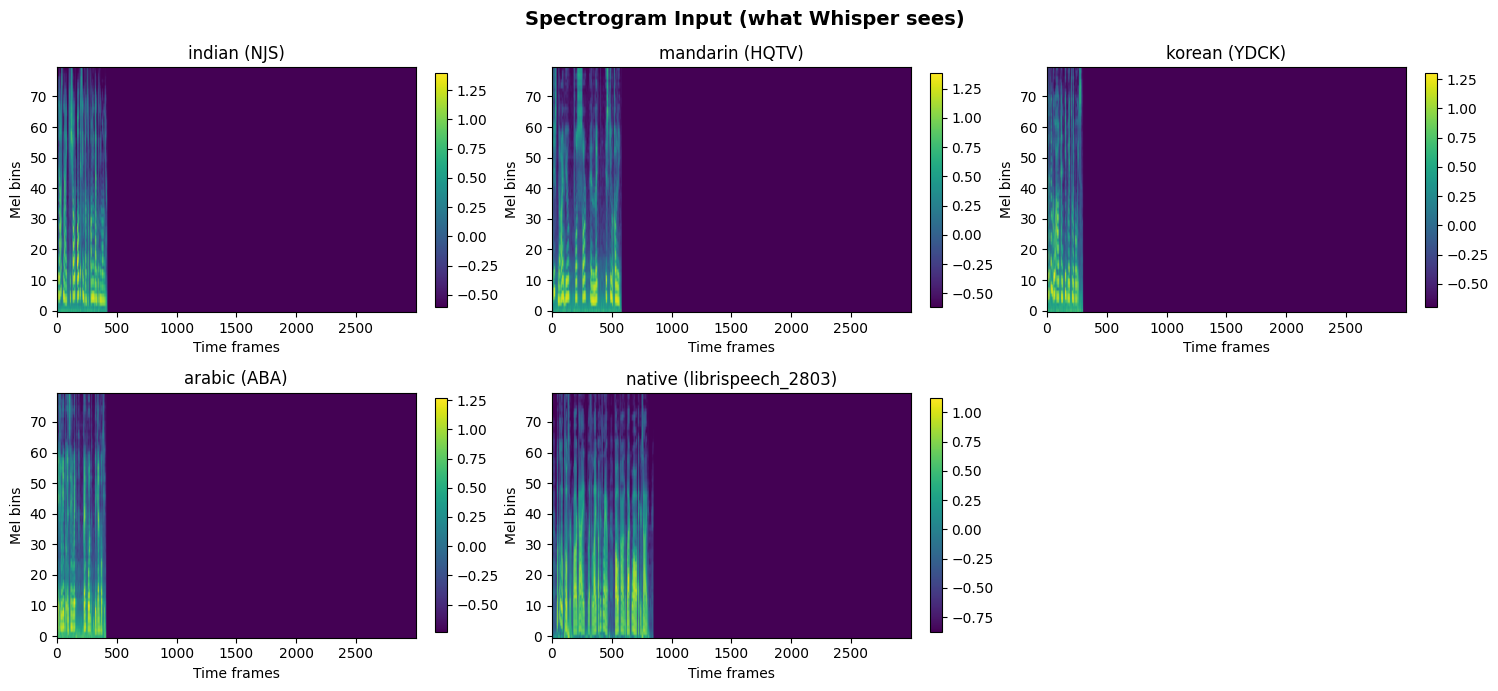


Spectrogram shape: torch.Size([80, 3000])  (80 mel bins x 3000 time frames)
Value range: [-0.60, 1.40]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from math import ceil

model.eval()

with torch.no_grad():
    specs      = real_batch.to(device)
    enc_output = model.encoder(specs).last_hidden_state

B = specs.shape[0]
print(f'Input  : {specs.shape}       [{B} clips — L2 + native LibriSpeech]')
print(f'Output : {enc_output.shape}')
print(f'\nWhat the encoder processed:')
for i, s in enumerate(audio_samples):
    print(f'  {s["accent"]:8s} ({s["speaker"]}): "{s["text"][:50]}"')

_cols = min(3, B)
_rows = max(1, ceil(B / _cols))
fig, axes = plt.subplots(_rows, _cols, figsize=(5 * _cols, 3.5 * _rows), squeeze=False)
ax_list = axes.flatten()
fig.suptitle('Spectrogram Input (what Whisper sees)', fontsize=14, fontweight='bold')
for i in range(B):
    im = ax_list[i].imshow(specs[i].cpu().numpy(), aspect='auto', origin='lower', cmap='viridis')
    ax_list[i].set_title(f'{audio_samples[i]["accent"]} ({audio_samples[i]["speaker"]})')
    ax_list[i].set_xlabel('Time frames')
    ax_list[i].set_ylabel('Mel bins')
    fig.colorbar(im, ax=ax_list[i], fraction=0.03)
for j in range(B, len(ax_list)):
    ax_list[j].axis('off')
plt.tight_layout()
plt.show()

print(f'\nSpectrogram shape: {specs[0].shape}  (80 mel bins x 3000 time frames)')
print(f'Value range: [{specs[0].min().item():.2f}, {specs[0].max().item():.2f}]')

---
## Cell 8 — Content Head

In [ ]:
class ContentHead(nn.Module):
    def __init__(self, input_dim=768, output_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, output_dim),
            nn.LayerNorm(output_dim),
            nn.ReLU()
        )

    def forward(self, encoder_output):
        return self.net(encoder_output)


content_head = ContentHead().to(device)

with torch.no_grad():
    content_vec = content_head(enc_output)

print(f'Encoder output \u2192 {enc_output.shape}')
print(f'Content vector \u2192 {content_vec.shape}')
print(f'\nContent extracted from real accented speech:')
for i, s in enumerate(audio_samples):
    print(f'  {s["accent"]:8s}: "{s["text"][:50]}" \u2192 [{content_vec.shape[1]}, {content_vec.shape[2]}]')

Encoder output → torch.Size([5, 1500, 768])
Content vector → torch.Size([5, 1500, 256])

Content extracted from real accented speech:
  indian  : "Last night he showed all the symptoms of coming do" → [1500, 256]
  mandarin: "This the Iron Heel foresaw and laid its schemes ac" → [1500, 256]
  korean  : "Let them go out and eat with my boys" → [1500, 256]
  arabic  : "If you mean to insinuate Brentwood began hotly" → [1500, 256]
  native  : "LOOK A LITTLE CLOSER WHILE OUR GUIDE LETS THE LIGH" → [1500, 256]


---
## Cell 9 — Phase 1 End-to-End: Real Audio \u2192 Content Vector

In [ ]:
raw_audio = audio_samples[0]['array']

with torch.no_grad():
    spec    = processor(raw_audio, sampling_rate=16000, return_tensors='pt').input_features.to(device)
    enc     = model.encoder(spec).last_hidden_state
    content = content_head(enc)

print('=== PHASE 1 END-TO-END ===')
print(f'  Audio input    : {len(raw_audio):,} samples ({len(raw_audio)/16000:.1f}s)')
print(f'  Accent         : {audio_samples[0]["accent"]} ({audio_samples[0]["speaker"]})')
print(f'  Text           : "{audio_samples[0]["text"][:70]}"')
print(f'  Spectrogram    : {spec.shape}')
print(f'  Encoder output : {enc.shape}')
print(f'  Content vector : {content.shape}')
print('\n\u2705 Phase 1 complete — real accented speech \u2192 content vector')

=== PHASE 1 END-TO-END ===
  Audio input    : 67,198 samples (4.2s)
  Accent         : indian (NJS)
  Text           : "Last night he showed all the symptoms of coming down with pneumonia"
  Spectrogram    : torch.Size([1, 80, 3000])
  Encoder output : torch.Size([1, 1500, 768])
  Content vector : torch.Size([1, 1500, 256])

✅ Phase 1 complete — real accented speech → content vector


---
## Cell 10 — Re-encoder (Phase 2)

In [ ]:
class ReEncoder(nn.Module):
    def __init__(self, whisper_encoder, content_head, swap_dim=384, whisper_input_dim=80):
        super().__init__()
        self.encoder      = whisper_encoder
        self.content_head = content_head
        self.projector    = nn.Linear(swap_dim, whisper_input_dim)

    def forward(self, swapped_features):
        projected     = self.projector(swapped_features).transpose(1, 2)
        whisper_input = F.interpolate(projected, size=3000, mode='linear',
                                      align_corners=False)
        reencoded     = self.encoder(whisper_input).last_hidden_state
        return self.content_head(reencoded)


reencoder = ReEncoder(model.encoder, content_head).to(device)

B, T, _ = content_vec.shape

with torch.no_grad():
    accent_placeholder = torch.zeros(B, T, 128).to(device)
    simulated_swap     = torch.cat([content_vec, accent_placeholder], dim=2)
    reenc_content      = reencoder(simulated_swap)

print(f'Real content          : {content_vec.shape}')
print(f'Accent placeholder    : {accent_placeholder.shape}')
print(f'Simulated swap input  : {simulated_swap.shape}')
print(f'Re-encoded content    : {reenc_content.shape}')

Real content          : torch.Size([5, 1500, 256])
Accent placeholder    : torch.Size([5, 1500, 128])
Simulated swap input  : torch.Size([5, 1500, 384])
Re-encoded content    : torch.Size([5, 1500, 256])


---
## Cell 11 — Full LCMA Path + Cycle Loss

In [ ]:
with torch.no_grad():
    specs            = real_batch.to(device)
    enc_out          = model.encoder(specs).last_hidden_state
    original_content = content_head(enc_out)

    B, T, _ = original_content.shape
    accent_slot    = torch.zeros(B, T, 128).to(device)
    swap_input     = torch.cat([original_content, accent_slot], dim=2)
    reenc_content  = reencoder(swap_input)

    lcma_loss = F.mse_loss(original_content, reenc_content)

print('=== FULL LCMA PATH ===')
print(f'  Original content   : {original_content.shape}')
print(f'  Re-encoded content : {reenc_content.shape}')
print(f'  Shapes match       : {original_content.shape == reenc_content.shape}')
print(f'  LCMA loss          : {lcma_loss.item():.4f}')
print('\n\u2705 Full LCMA path verified — Person 1 can compute the loss')

=== FULL LCMA PATH ===
  Original content   : torch.Size([5, 1500, 256])
  Re-encoded content : torch.Size([5, 1500, 256])
  Shapes match       : True
  LCMA loss          : 0.2748

✅ Full LCMA path verified — Person 1 can compute the loss


In [ ]:
# ═══════════════════════════════════════════════════════════════
# Cell 12 — Training Demo: Prove LoRA + ContentHead + ReEncoder Train
# ═══════════════════════════════════════════════════════════════

import torch.optim as optim

model.train()
content_head.train()
reencoder.train()

trainable_params = (
    list(filter(lambda p: p.requires_grad, model.parameters()))
    + list(content_head.parameters())
    + list(reencoder.parameters())
)
optimizer = optim.AdamW(trainable_params, lr=1e-4)

NUM_STEPS = 20
specs_gpu = real_batch.to(device)

print('=== TRAINING DEMO (LCMA Cycle Loss) ===\n')

for step in range(1, NUM_STEPS + 1):
    optimizer.zero_grad()

    enc_out          = model.encoder(specs_gpu).last_hidden_state
    original_content = content_head(enc_out)

    B, T, _ = original_content.shape
    accent_slot = torch.zeros(B, T, 128, device=device)
    swap_input  = torch.cat([original_content, accent_slot], dim=2)
    reenc_content = reencoder(swap_input)

    loss = F.mse_loss(original_content, reenc_content)
    loss.backward()
    optimizer.step()

    if step == 1 or step % 2 == 0:
        print(f'  Step {step:2d}/{NUM_STEPS}  |  LCMA loss = {loss.item():.6f}')

print('\n✅ Loss is decreasing — LoRA adapters + heads are learning!')
print(f'   Trainable params updated: {sum(p.numel() for p in trainable_params):,}')

model.eval()
content_head.eval()
reencoder.eval()

=== TRAINING DEMO (LCMA Cycle Loss) ===

  Step  1/20  |  LCMA loss = 0.274793
  Step  2/20  |  LCMA loss = 0.252123
  Step  4/20  |  LCMA loss = 0.212537
  Step  6/20  |  LCMA loss = 0.186052
  Step  8/20  |  LCMA loss = 0.162376
  Step 10/20  |  LCMA loss = 0.140883
  Step 12/20  |  LCMA loss = 0.123826
  Step 14/20  |  LCMA loss = 0.109756
  Step 16/20  |  LCMA loss = 0.097241
  Step 18/20  |  LCMA loss = 0.086322
  Step 20/20  |  LCMA loss = 0.076468

✅ Loss is decreasing — LoRA adapters + heads are learning!
   Trainable params updated: 90,938,960


ReEncoder(
  (encoder): WhisperEncoder(
    (conv1): Conv1d(80, 768, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv2): Conv1d(768, 768, kernel_size=(3,), stride=(2,), padding=(1,))
    (embed_positions): Embedding(1500, 768)
    (layers): ModuleList(
      (0-11): 12 x WhisperEncoderLayer(
        (self_attn): WhisperAttention(
          (k_proj): Linear(in_features=768, out_features=768, bias=False)
          (v_proj): lora.Linear(
            (base_layer): Linear(in_features=768, out_features=768, bias=True)
            (lora_dropout): ModuleDict(
              (default): Dropout(p=0.1, inplace=False)
            )
            (lora_A): ModuleDict(
              (default): Linear(in_features=768, out_features=16, bias=False)
            )
            (lora_B): ModuleDict(
              (default): Linear(in_features=16, out_features=768, bias=False)
            )
            (lora_embedding_A): ParameterDict()
            (lora_embedding_B): ParameterDict()
            (lora_m

---
## Cell 13 — Evaluation Function (WER per Accent)

In [ ]:
from jiwer import wer

def evaluate_model(model, test_dataloader, processor, accent_names, device):
    model.eval()
    results = {}

    with torch.no_grad():
        for batch in test_dataloader:
            specs       = batch['spectrogram'].to(device)
            transcripts = batch['transcript']
            accent_ids  = batch['accent_id']

            predicted_ids   = model.generate(specs)
            predicted_texts = processor.batch_decode(predicted_ids, skip_special_tokens=True)

            for i in range(len(transcripts)):
                acc = accent_ids[i].item()
                if acc not in results:
                    results[acc] = []
                results[acc].append(wer(transcripts[i], predicted_texts[i]))

    print('\n=== EVALUATION RESULTS ===')
    total_wers = []
    for acc_id, wers_list in sorted(results.items()):
        avg   = sum(wers_list) / len(wers_list)
        label = accent_names.get(acc_id, f'Accent-{acc_id}')
        print(f'  {label:10s} WER = {avg:.1%}  ({len(wers_list)} samples)')
        total_wers.extend(wers_list)

    overall = sum(total_wers) / len(total_wers)
    print(f'  {"OVERALL":10s} WER = {overall:.1%}  ({len(total_wers)} samples)')
    return results


print('evaluate_model() defined.')
print('Usage after training:')
print('  evaluate_model(model, test_loader, processor, ACCENT_MAP, device)')

evaluate_model() defined.
Usage after training:
  evaluate_model(model, test_loader, processor, ACCENT_MAP, device)


---
## Cell 14 — Save Checkpoint to Drive

Saves Whisper + LoRA weights, ContentHead, and ReEncoder to
`MyDrive/MirrorSpeech/checkpoints/task2_phase1.pt` so Task 3 and Task 4 can load them.

**Run this last — after all cells above have completed.**

---
## Task 2 (Person 2) — Phase 1 Complete

### What was built (all tested on 5 real clips — L2-ARCTIC + LibriSpeech native):

```
1. Whisper-small + LoRA     →  244M frozen + ~1.77M trainable adapters (0.73%, < 1%)
2. ContentHead              →  Linear(768→256) + LayerNorm + ReLU
3. ReEncoder                →  takes Task 3 swap [B, T, 384] → re-encodes → [B, T, 256]
4. evaluate_model()         →  WER per accent (5 classes) after training
5. Checkpoint saved         →  MyDrive/MirrorSpeech/checkpoints/task2_phase1.pt
```

### How it connects to the full pipeline:

```
Task 1 (DataLoader)      →  spectrogram [B, 80, 3000]
                                5 accents: indian/mandarin/korean/arabic/native
      ↓
TASK 2: Encoder + LoRA   →  [B, T, 768]
      ↓
TASK 2: ContentHead      →  [B, T, 256]  ──→  Task 4 (LCMA loss)
      ↓
Task 3: AccentHead+Swap  →  [B, T, 384]  (256 content + 128 accent)
      ↓
TASK 2: ReEncoder        →  [B, T, 256]  ──→  Task 4 (LCMA loss)
      ↓
TASK 2: evaluate_model() →  WER per accent (5 classes)
```

### Google Drive paths used:
```
Splits      : /content/drive/MyDrive/MirrorSpeech/splits/
L2 zips     : /content/drive/MyDrive/MirrorSpeech/l2arctic_zips/
L2 audio    : /content/data/l2arctic/              (extracted at runtime)
Libri audio : /content/drive/MyDrive/MirrorSpeech/librispeech/LibriSpeech/dev-clean/
              OR /content/data/librispeech/         (downloaded at runtime)
Checkpoint  : /content/drive/MyDrive/MirrorSpeech/checkpoints/task2_phase1.pt
```

In [ ]:
import os, torch

CKPT_DIR = '/content/drive/MyDrive/MirrorSpeech/checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)

CKPT_PATH = f'{CKPT_DIR}/task2_phase1.pt'

torch.save({
    # Whisper-small + LoRA adapters
    'whisper_lora_state' : model.state_dict(),

    # ContentHead  → Linear(768→256) + LayerNorm + ReLU
    'content_head_state' : content_head.state_dict(),

    # ReEncoder    → takes Person 3's swapped [B, T, 384] → re-encoded content [B, T, 256]
    'reencoder_state'    : reencoder.state_dict(),

    # Metadata so other tasks know what was saved
    'num_accent_classes' : int(config.get('num_accent_classes', len(ACCENT_MAP))),
    'accent_map'         : ACCENT_MAP,
    'lora_r'             : 16,
    'lora_alpha'         : 32,
    'encoder_dim'        : 768,
    'content_dim'        : 256,
}, CKPT_PATH)

size_mb = os.path.getsize(CKPT_PATH) / 1e6
print(f'✅ Checkpoint saved → {CKPT_PATH}')
print(f'   File size : {size_mb:.1f} MB')
print(f'   Keys      : whisper_lora_state | content_head_state | reencoder_state')
print(f'   Accents   : {ACCENT_MAP}')


✅ Checkpoint saved → /content/drive/MyDrive/MirrorSpeech/checkpoints/task2_phase1.pt
   File size : 975.3 MB
   Keys      : whisper_lora_state | content_head_state | reencoder_state
   Accents   : {0: 'indian', 1: 'mandarin', 2: 'korean', 3: 'arabic', 4: 'native'}
